In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
infected_df = pd.read_csv("data/infected_timeseries.csv")
rewiring_df = pd.read_csv("data/rewiring_timeseries.csv")
degree_df = pd.read_csv("data/final_degree_histograms.csv")

print("infected_df shape:", infected_df.shape)
print("rewiring_df shape:", rewiring_df.shape)
print("degree_df shape:", degree_df.shape)

infected_df shape: (8040, 3)
rewiring_df shape: (8040, 3)
degree_df shape: (1240, 3)


# 1. Observed data exploration

In [11]:
infected_df.head()

,replicate_id,time,infected_fraction
0,0,0,0.025
1,0,1,0.050
2,0,2,0.090
3,0,3,0.150
4,0,4,0.195


In [12]:
rewiring_df.head()

,replicate_id,time,rewire_count
0,0,0,0
1,0,1,32
2,0,2,28
3,0,3,50
4,0,4,53


In [13]:
degree_df.head()

,replicate_id,degree,count
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,4


### All infected trajectories

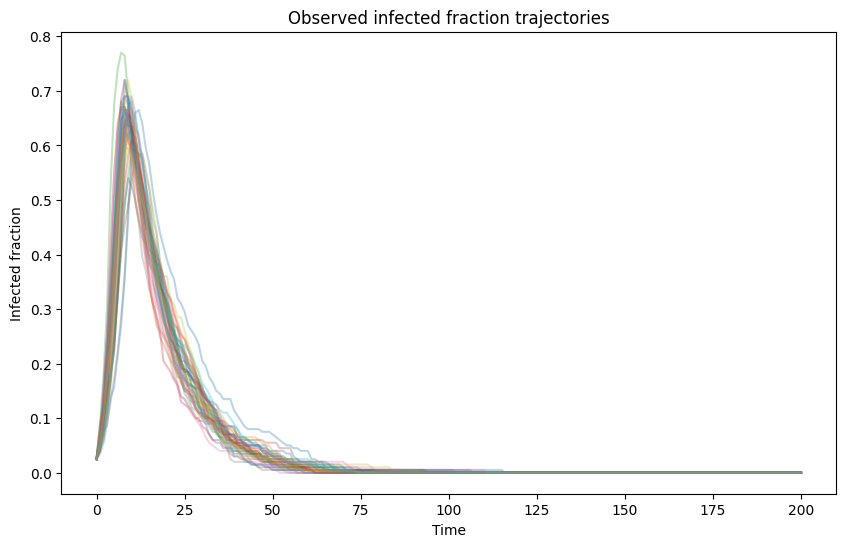

In [18]:
plt.figure(figsize=(10, 6))

for rid, grp in infected_df.groupby("replicate_id"):
    grp = grp.sort_values("time")
    plt.plot(grp["time"], grp["infected_fraction"], alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Observed infected fraction trajectories")
plt.show()

### Mean infected trajectory

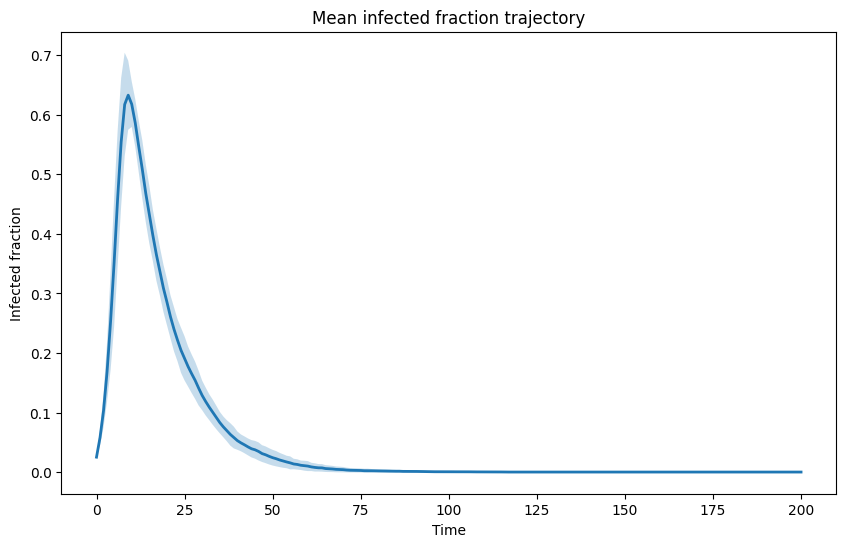

In [19]:
infected_pivot = infected_df.pivot(index="time", columns="replicate_id", values="infected_fraction")
infected_mean = infected_pivot.mean(axis=1)
infected_sd = infected_pivot.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(infected_mean.index, infected_mean.values, linewidth=2)
plt.fill_between(
    infected_mean.index,
    infected_mean - infected_sd,
    infected_mean + infected_sd,
    alpha=0.25
)
plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Mean infected fraction trajectory")
plt.show()

### All rewiring trajectories

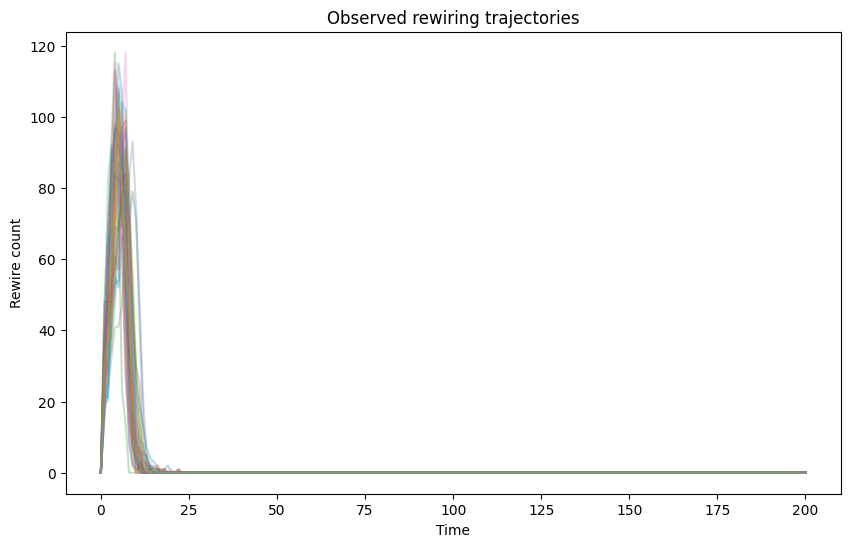

In [20]:
plt.figure(figsize=(10, 6))

for rid, grp in rewiring_df.groupby("replicate_id"):
    grp = grp.sort_values("time")
    plt.plot(grp["time"], grp["rewire_count"], alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Rewire count")
plt.title("Observed rewiring trajectories")
plt.show()

### Mean rewiring trajectory

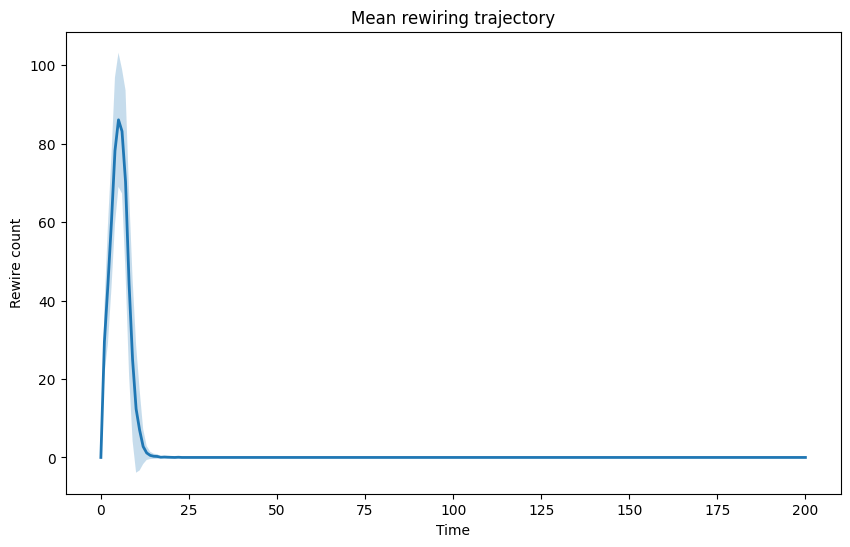

In [21]:
rewiring_pivot = rewiring_df.pivot(index="time", columns="replicate_id", values="rewire_count")
rewiring_mean = rewiring_pivot.mean(axis=1)
rewiring_sd = rewiring_pivot.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(rewiring_mean.index, rewiring_mean.values, linewidth=2)
plt.fill_between(
    rewiring_mean.index,
    rewiring_mean - rewiring_sd,
    rewiring_mean + rewiring_sd,
    alpha=0.25
)
plt.xlabel("Time")
plt.ylabel("Rewire count")
plt.title("Mean rewiring trajectory")
plt.show()

### Average final degree histogram

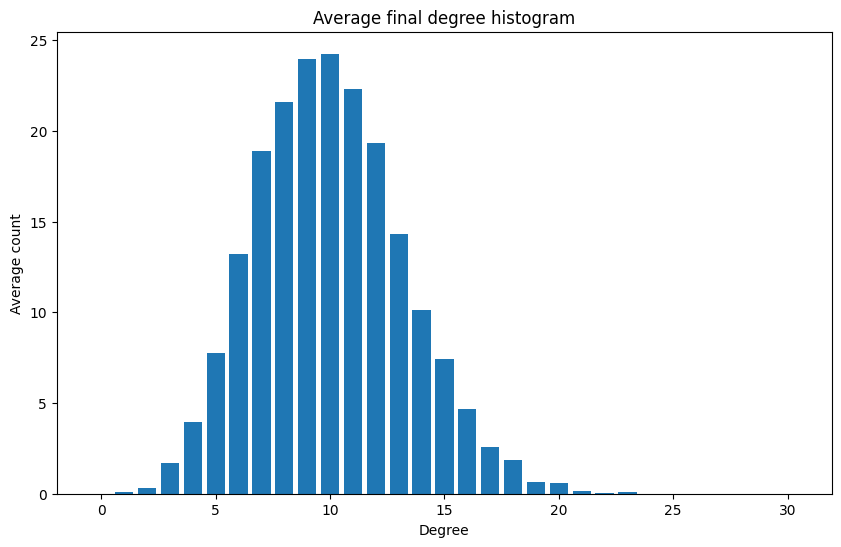

In [22]:
degree_pivot = degree_df.pivot(index="degree", columns="replicate_id", values="count")
degree_mean = degree_pivot.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.bar(degree_mean.index, degree_mean.values)
plt.xlabel("Degree")
plt.ylabel("Average count")
plt.title("Average final degree histogram")
plt.show()

# 2. Simulator exploration

In [23]:
import simulator
print(dir(simulator))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np', 'simulate']


In [24]:
help(simulator)

Help on module simulator:

NAME
    simulator - Adaptive-network SIR epidemic simulator.

DESCRIPTION
    This module simulates an SIR (Susceptible-Infected-Recovered) epidemic
    spreading on a network that evolves over time. The key idea is that
    susceptible individuals can "rewire" their connections to avoid infected
    neighbors, which couples the disease dynamics with the network topology.
    
    The model proceeds in discrete time steps, each with three phases:
      1. Infection: infected nodes transmit the disease to susceptible neighbors
      2. Recovery: infected nodes recover (and become immune)
      3. Rewiring: susceptible nodes break links with infected neighbors and
         form new connections elsewhere
    
    Reference: Gross et al. (2006), "Epidemic dynamics on an adaptive network",
    Physical Review Letters, 96(20), 208701.

FUNCTIONS
    simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None)
        Run one replicate of the adap

### test one simulation

In [25]:

inf_curve, rew_curve, deg_hist = simulator.simulate(beta=0.2, gamma=0.05, rho=0.25)

print(inf_curve.shape, rew_curve.shape, deg_hist.shape)
print("first 10 infected values:", inf_curve[:10])
print("first 10 rewiring values:", rew_curve[:10])
print("degree histogram sum:", deg_hist.sum())

(201,) (201,) (31,)
first 10 infected values: [0.025 0.085 0.14  0.255 0.455 0.685 0.815 0.85  0.785 0.76 ]
first 10 rewiring values: [ 0 39 51 91 77 84 29  8  1  0]
degree histogram sum: 200


### plot one simulated run

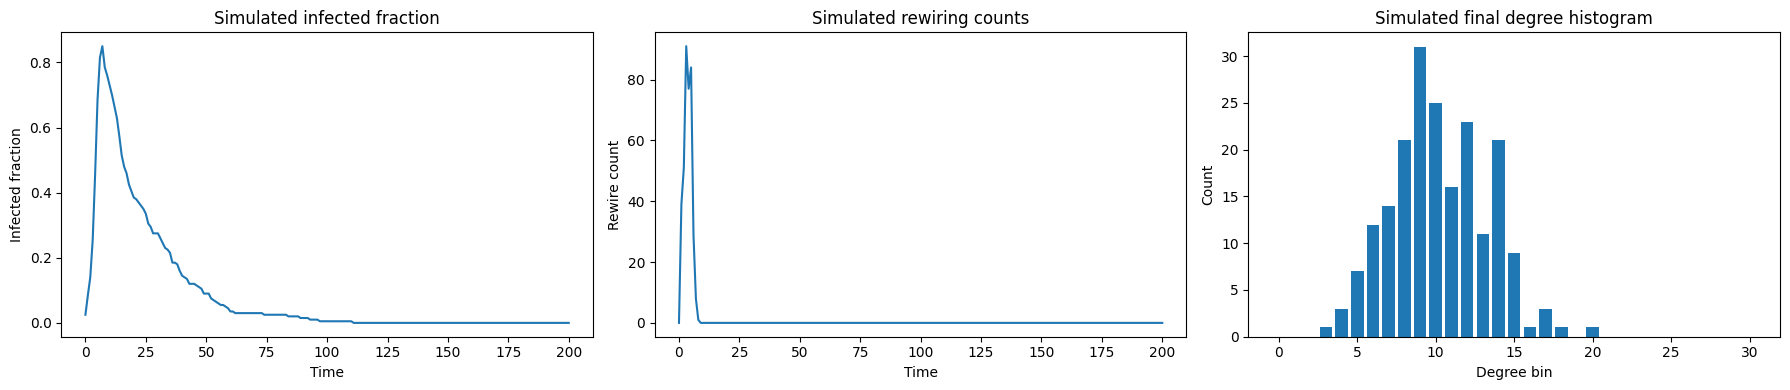

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(inf_curve)
axes[0].set_title("Simulated infected fraction")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Infected fraction")

axes[1].plot(rew_curve)
axes[1].set_title("Simulated rewiring counts")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Rewire count")

axes[2].bar(np.arange(len(deg_hist)), deg_hist)
axes[2].set_title("Simulated final degree histogram")
axes[2].set_xlabel("Degree bin")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 3. Summary statistics

In [27]:
def summarize_infected_curve(curve):
    curve = np.asarray(curve)
    return np.array([
        curve.max(),        # peak infected fraction
        curve.argmax(),     # time to peak
        curve.sum(),        # area under curve
        curve[-1],          # final infected fraction
        curve[5],
        curve[10],
        curve[20],
        curve[40],
    ], dtype=float)


def summarize_rewiring_curve(curve):
    curve = np.asarray(curve)
    return np.array([
        curve.max(),        # peak rewiring
        curve.argmax(),     # time to peak rewiring
        curve.sum(),        # total rewiring
        curve[-1],          # final rewiring count
        curve[5],
        curve[10],
        curve[20],
        curve[40],
    ], dtype=float)


def summarize_degree_hist(hist):
    hist = np.asarray(hist, dtype=float)
    probs = hist / hist.sum()
    degrees = np.arange(len(hist))

    mean_deg = np.sum(degrees * probs)
    var_deg = np.sum((degrees - mean_deg) ** 2 * probs)

    return np.array([
        mean_deg,
        var_deg,
        probs[:5].sum(),      # low degrees
        probs[5:11].sum(),    # middle degrees
        probs[11:].sum(),     # high degrees
    ], dtype=float)

In [7]:
def make_summary(inf_curve, rew_curve, deg_hist,
                 use_infected=True, use_rewiring=True, use_degree=True):
    parts = []

    if use_infected:
        parts.append(summarize_infected_curve(inf_curve))
    if use_rewiring:
        parts.append(summarize_rewiring_curve(rew_curve))
    if use_degree:
        parts.append(summarize_degree_hist(deg_hist))

    return np.concatenate(parts)

In [28]:
infected_obs = {}
for rid, grp in infected_df.groupby("replicate_id"):
    infected_obs[rid] = grp.sort_values("time")["infected_fraction"].to_numpy()

rewiring_obs = {}
for rid, grp in rewiring_df.groupby("replicate_id"):
    rewiring_obs[rid] = grp.sort_values("time")["rewire_count"].to_numpy()

degree_obs = {}
for rid, grp in degree_df.groupby("replicate_id"):
    degree_obs[rid] = grp.sort_values("degree")["count"].to_numpy()

rep_ids = sorted(set(infected_obs) & set(rewiring_obs) & set(degree_obs))
print("Number of common replicate IDs:", len(rep_ids))

Number of common replicate IDs: 40


In [29]:
rid0 = rep_ids[0]

s_test_inf_only = make_summary(
    infected_obs[rid0],
    rewiring_obs[rid0],
    degree_obs[rid0],
    use_infected=True,
    use_rewiring=False,
    use_degree=False
)

s_test_inf_rew = make_summary(
    infected_obs[rid0],
    rewiring_obs[rid0],
    degree_obs[rid0],
    use_infected=True,
    use_rewiring=True,
    use_degree=False
)

s_test_full = make_summary(
    infected_obs[rid0],
    rewiring_obs[rid0],
    degree_obs[rid0],
    use_infected=True,
    use_rewiring=True,
    use_degree=True
)

print("infected-only summary length:", len(s_test_inf_only))
print("infected + rewiring summary length:", len(s_test_inf_rew))
print("full summary length:", len(s_test_full))

print("infected-only summary:", s_test_inf_only)

infected-only summary length: 8
infected + rewiring summary length: 16
full summary length: 21
infected-only summary: [0.54  9.    9.905 0.    0.24  0.525 0.305 0.04 ]


In [30]:
def observed_average_summary(use_infected=True, use_rewiring=True, use_degree=True):
    summaries = []

    for rid in rep_ids:
        s = make_summary(
            infected_obs[rid],
            rewiring_obs[rid],
            degree_obs[rid],
            use_infected=use_infected,
            use_rewiring=use_rewiring,
            use_degree=use_degree
        )
        summaries.append(s)

    summaries = np.vstack(summaries)
    return summaries.mean(axis=0), summaries

In [31]:
obs_sum_inf_only, obs_mat_inf_only = observed_average_summary(
    use_infected=True,
    use_rewiring=False,
    use_degree=False
)

obs_sum_inf_rew, obs_mat_inf_rew = observed_average_summary(
    use_infected=True,
    use_rewiring=True,
    use_degree=False
)

obs_sum_full, obs_mat_full = observed_average_summary(
    use_infected=True,
    use_rewiring=True,
    use_degree=True
)

print("infected-only observed summary length:", len(obs_sum_inf_only))
print("infected + rewiring observed summary length:", len(obs_sum_inf_rew))
print("full observed summary length:", len(obs_sum_full))

infected-only observed summary length: 8
infected + rewiring observed summary length: 16
full observed summary length: 21


In [32]:
print("Observed infected-only summary:")
print(obs_sum_inf_only)

print("\nObserved infected + rewiring summary:")
print(obs_sum_inf_rew)

print("\nObserved full summary:")
print(obs_sum_full)

Observed infected-only summary:
[ 0.657125  8.75     11.399     0.        0.35175   0.61775   0.285375
  0.05275 ]

Observed infected + rewiring summary:
[6.57125e-01 8.75000e+00 1.13990e+01 0.00000e+00 3.51750e-01 6.17750e-01
 2.85375e-01 5.27500e-02 9.81250e+01 5.50000e+00 5.45150e+02 0.00000e+00
 8.60750e+01 1.23750e+01 2.50000e-02 0.00000e+00]

Observed full summary:
[6.57125000e-01 8.75000000e+00 1.13990000e+01 0.00000000e+00
 3.51750000e-01 6.17750000e-01 2.85375000e-01 5.27500000e-02
 9.81250000e+01 5.50000000e+00 5.45150000e+02 0.00000000e+00
 8.60750000e+01 1.23750000e+01 2.50000000e-02 0.00000000e+00
 1.00172500e+01 1.03410225e+01 3.05000000e-02 5.48375000e-01
 4.21125000e-01]


In [33]:
# --- Figure 1 exact observed quantities ---

# convert dicts to matrices
rep_ids = sorted(infected_obs.keys())
infected_mat = np.vstack([infected_obs[rid] for rid in rep_ids])
rewiring_mat = np.vstack([rewiring_obs[rid] for rid in rep_ids])
degree_mat = np.vstack([degree_obs[rid] for rid in rep_ids])

# means for plotting Figure 1
infected_mean = infected_mat.mean(axis=0)
rewiring_mean = rewiring_mat.mean(axis=0)
degree_mean = degree_mat.mean(axis=0)

print("Figure 1 plotting arrays ready:")
print("infected_mean shape:", infected_mean.shape)
print("rewiring_mean shape:", rewiring_mean.shape)
print("degree_mean shape:", degree_mean.shape)

print("\nExact summary values to cite in report:")
print("Infected peak:", obs_sum_inf_only[0])
print("Infected peak time:", obs_sum_inf_only[1])
print("Infected AUC:", obs_sum_inf_only[2])

print("Rewiring peak:", obs_sum_inf_rew[8])
print("Rewiring peak time:", obs_sum_inf_rew[9])
print("Total rewiring:", obs_sum_inf_rew[10])

print("Mean degree:", obs_sum_full[16])
print("Degree variance:", obs_sum_full[17])
print("Low-degree mass:", obs_sum_full[18])
print("Middle-degree mass:", obs_sum_full[19])
print("High-degree mass:", obs_sum_full[20])

Figure 1 plotting arrays ready:
infected_mean shape: (201,)
rewiring_mean shape: (201,)
degree_mean shape: (31,)

Exact summary values to cite in report:
Infected peak: 0.6571249999999998
Infected peak time: 8.75
Infected AUC: 11.399
Rewiring peak: 98.125
Rewiring peak time: 5.5
Total rewiring: 545.15
Mean degree: 10.017249999999999
Degree variance: 10.341022500000001
Low-degree mass: 0.0305
Middle-degree mass: 0.5483750000000001
High-degree mass: 0.42112499999999997


##### Infected-Only Summary
 
On average across the 40 replicates:
 
- Peak infected fraction ≈ 0.657
- Peak happens around time 8.75
- Total infected burden (area under curve) ≈ 11.399
- Final infected fraction = 0, which makes sense because outbreaks die out
 
##### Infected + Rewiring Summary
 
The rewiring part says roughly:
 
- Peak rewiring count ≈ 98.1
- Peak rewiring time ≈ 5.5
- Total rewiring ≈ 545.15
- Rewiring is essentially 0 by later times

 
##### Full Summary
 
The degree part says roughly:
 
- Mean degree ≈ 10.02
- Variance ≈ 10.34
- Low-degree mass ≈ 0.0305
- Middle-degree mass ≈ 0.548
- High-degree mass ≈ 0.421 
 

# 4. Basic rejection ABC

In [34]:
def sample_prior(n, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    beta = rng.uniform(0.05, 0.50, size=n)
    gamma = rng.uniform(0.02, 0.20, size=n)
    rho = rng.uniform(0.00, 0.80, size=n)

    return np.column_stack([beta, gamma, rho])

In [35]:
#test
rng = np.random.default_rng(123)
theta_test = sample_prior(5, rng=rng)
theta_test

array([[0.35705834, 0.16617701, 0.41037636],
       [0.07421946, 0.1862021 , 0.19597168],
       [0.14916194, 0.06978339, 0.65939328],
       [0.13296731, 0.16755582, 0.17101037],
       [0.12915766, 0.18018068, 0.59317364]])

In [36]:
# simulate multiple replicates and average their summaries
def simulate_average_summary(beta, gamma, rho, n_reps=20,
                             use_infected=True, use_rewiring=True, use_degree=True,
                             rng=None):
    if rng is None:
        rng = np.random.default_rng()

    summaries = []

    for _ in range(n_reps):
        inf_curve, rew_curve, deg_hist = simulator.simulate(
            beta=beta, gamma=gamma, rho=rho, rng=rng
        )

        s = make_summary(
            inf_curve, rew_curve, deg_hist,
            use_infected=use_infected,
            use_rewiring=use_rewiring,
            use_degree=use_degree
        )
        summaries.append(s)

    summaries = np.vstack(summaries)
    return summaries.mean(axis=0)

In [37]:
# test
rng = np.random.default_rng(123)

sim_sum_test = simulate_average_summary(
    beta=0.2, gamma=0.05, rho=0.25,
    n_reps=5,
    use_infected=True,
    use_rewiring=False,
    use_degree=False,
    rng=rng
)

print("summary length:", len(sim_sum_test))
print(sim_sum_test)

summary length: 8
[ 0.8    7.2   18.263  0.     0.57   0.714  0.418  0.142]


In [38]:
# estimate scale for normalization
def estimate_summary_scale(n_pilot=200, n_reps=10,
                           use_infected=True, use_rewiring=True, use_degree=True,
                           rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = sample_prior(n_pilot, rng=rng)
    sim_summaries = []

    for beta, gamma, rho in theta:
        s = simulate_average_summary(
            beta, gamma, rho,
            n_reps=n_reps,
            use_infected=use_infected,
            use_rewiring=use_rewiring,
            use_degree=use_degree,
            rng=rng
        )
        sim_summaries.append(s)

    sim_summaries = np.vstack(sim_summaries)
    scale = sim_summaries.std(axis=0)
    scale[scale == 0] = 1.0
    return scale

In [39]:
# test on infected only
rng = np.random.default_rng(123)

scale_inf_only = estimate_summary_scale(
    n_pilot=50,
    n_reps=5,
    use_infected=True,
    use_rewiring=False,
    use_degree=False,
    rng=rng
)

print("scale length:", len(scale_inf_only))
print(scale_inf_only)

scale length: 8
[2.39777060e-01 4.36393217e+00 1.04119924e+01 2.66300582e-03
 2.71496158e-01 2.25891900e-01 1.89025544e-01 1.20573357e-01]


In [40]:
# define the normalized distance
def normalized_distance(sim_summary, obs_summary, scale):
    z = (sim_summary - obs_summary) / scale
    return np.sqrt(np.sum(z ** 2))

In [41]:
# test
d_test = normalized_distance(sim_sum_test, obs_sum_inf_only, scale_inf_only)
print(d_test)

1.6684648675121123


In [42]:
# rejection ABC function
def rejection_abc(n_samples, obs_summary, scale, n_reps_per_theta=10,
                  use_infected=True, use_rewiring=True, use_degree=True,
                  rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = sample_prior(n_samples, rng=rng)
    distances = np.zeros(n_samples)

    for i, (beta, gamma, rho) in enumerate(theta):
        sim_summary = simulate_average_summary(
            beta, gamma, rho,
            n_reps=n_reps_per_theta,
            use_infected=use_infected,
            use_rewiring=use_rewiring,
            use_degree=use_degree,
            rng=rng
        )

        distances[i] = normalized_distance(sim_summary, obs_summary, scale)

        if (i + 1) % 100 == 0:
            print(f"Done {i+1}/{n_samples}")

    return theta, distances

In [43]:
# run the first infected-only ABC
rng = np.random.default_rng(123)

scale_inf_only = estimate_summary_scale(
    n_pilot=100,
    n_reps=5,
    use_infected=True,
    use_rewiring=False,
    use_degree=False,
    rng=rng
)

theta_inf_only, dist_inf_only = rejection_abc(
    n_samples=500,
    obs_summary=obs_sum_inf_only,
    scale=scale_inf_only,
    n_reps_per_theta=5,
    use_infected=True,
    use_rewiring=False,
    use_degree=False,
    rng=rng
)

Done 100/500
Done 200/500
Done 300/500
Done 400/500
Done 500/500


In [44]:
# accept the closest 2%
eps_inf_only = np.quantile(dist_inf_only, 0.02)
accepted_inf_only = theta_inf_only[dist_inf_only <= eps_inf_only]

print("epsilon:", eps_inf_only)
print("accepted samples:", len(accepted_inf_only))
print("posterior mean [beta, gamma, rho]:", accepted_inf_only.mean(axis=0))

epsilon: 0.6652935135811818
accepted samples: 10
posterior mean [beta, gamma, rho]: [0.18766666 0.0828775  0.38161398]


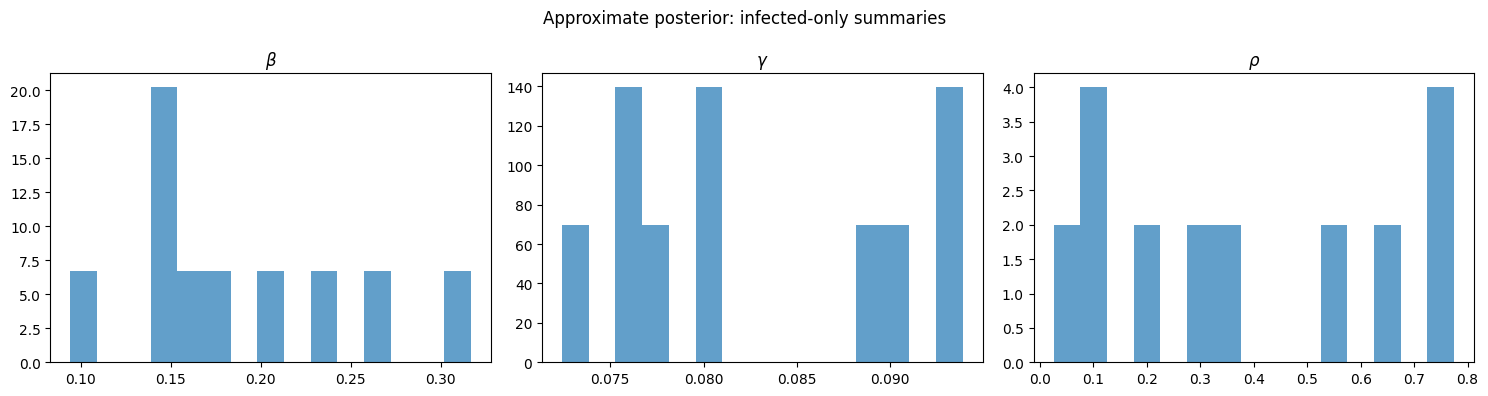

In [40]:
# plot marginal histograms
param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j in range(3):
    axes[j].hist(accepted_inf_only[:, j], bins=15, density=True, alpha=0.7)
    axes[j].set_title(param_names[j])

plt.suptitle("Approximate posterior: infected-only summaries")
plt.tight_layout()
plt.show()

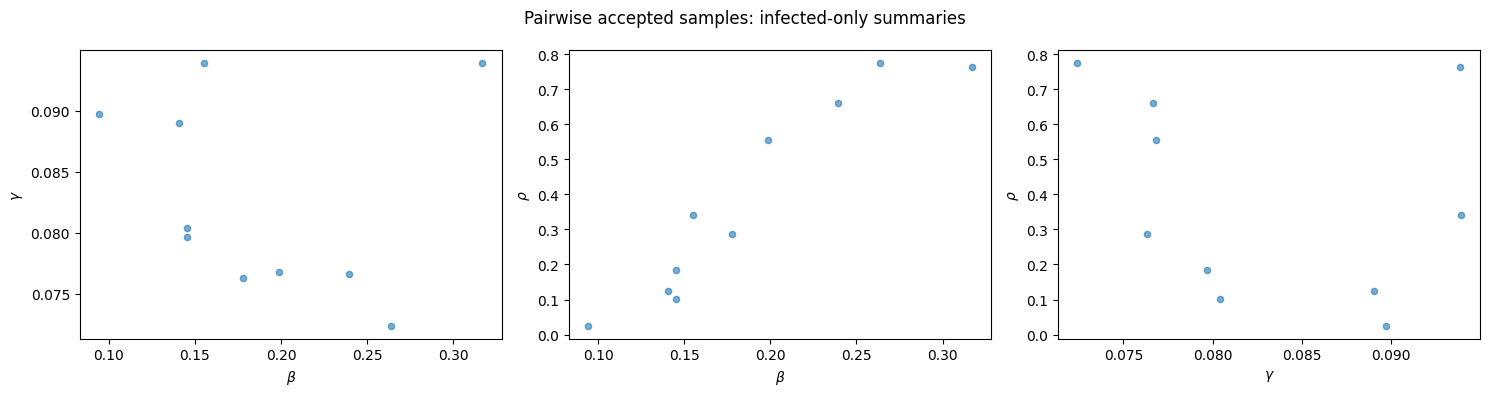

In [41]:
# pairwise plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(accepted_inf_only[:, 0], accepted_inf_only[:, 1], alpha=0.6, s=20)
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel(r"$\gamma$")

axes[1].scatter(accepted_inf_only[:, 0], accepted_inf_only[:, 2], alpha=0.6, s=20)
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"$\rho$")

axes[2].scatter(accepted_inf_only[:, 1], accepted_inf_only[:, 2], alpha=0.6, s=20)
axes[2].set_xlabel(r"$\gamma$")
axes[2].set_ylabel(r"$\rho$")

plt.suptitle("Pairwise accepted samples: infected-only summaries")
plt.tight_layout()
plt.show()

#### Infected-Only ABC: Preliminary Interpretation

- The infected-only rejection ABC posterior is relatively concentrated in γ, suggesting that outbreak timing and duration contain useful information about the recovery rate.
- The posterior for ρ remains broad, indicating that infected trajectories alone do not strongly identify the rewiring parameter.
- The β–ρ pairwise plot suggests confounding, with higher transmission rates often paired with higher rewiring rates among accepted samples.
- This supports the claim that infected-fraction summaries alone may be insufficient to separate β and ρ.

# 5. Summary-set comparison
## Compare 3 summary-statistics designs
1. infected-only 2. infected + rewiring 3. infected + rewiring + degree

In [45]:
# Full summary scales for each summary set
rng = np.random.default_rng(123)

scale_inf_only = estimate_summary_scale(
    n_pilot=100,
    n_reps=5,
    use_infected=True,
    use_rewiring=False,
    use_degree=False,
    rng=rng
)

scale_inf_rew = estimate_summary_scale(
    n_pilot=100,
    n_reps=5,
    use_infected=True,
    use_rewiring=True,
    use_degree=False,
    rng=rng
)

scale_full = estimate_summary_scale(
    n_pilot=100,
    n_reps=5,
    use_infected=True,
    use_rewiring=True,
    use_degree=True,
    rng=rng
)

In [97]:
# Rejection ABC: infected-only
rng = np.random.default_rng(123)

theta_inf_only, dist_inf_only = rejection_abc(
    n_samples=500,
    obs_summary=obs_sum_inf_only,
    scale=scale_inf_only,
    n_reps_per_theta=5,
    use_infected=True,
    use_rewiring=False,
    use_degree=False,
    rng=rng
)

eps_inf_only = np.quantile(dist_inf_only, 0.02)
accepted_inf_only = theta_inf_only[dist_inf_only <= eps_inf_only]

print("infected-only epsilon:", eps_inf_only)
print("infected-only accepted samples:", len(accepted_inf_only))
print("infected-only posterior mean:", accepted_inf_only.mean(axis=0))
print("infected-only posterior std :", accepted_inf_only.std(axis=0))

Done 100/500
Done 200/500
Done 300/500
Done 400/500
Done 500/500
infected-only epsilon: 0.8927824986867151
infected-only accepted samples: 10
infected-only posterior mean: [0.19489434 0.08217336 0.40101972]
infected-only posterior std : [0.05647753 0.01213218 0.24988182]


In [98]:
# Rejection ABC: infected + rewiring
rng = np.random.default_rng(123)

theta_inf_rew, dist_inf_rew = rejection_abc(
    n_samples=500,
    obs_summary=obs_sum_inf_rew,
    scale=scale_inf_rew,
    n_reps_per_theta=5,
    use_infected=True,
    use_rewiring=True,
    use_degree=False,
    rng=rng
)

eps_inf_rew = np.quantile(dist_inf_rew, 0.02)
accepted_inf_rew = theta_inf_rew[dist_inf_rew <= eps_inf_rew]

print("infected + rewiring epsilon:", eps_inf_rew)
print("infected + rewiring accepted samples:", len(accepted_inf_rew))
print("infected + rewiring posterior mean:", accepted_inf_rew.mean(axis=0))
print("infected + rewiring posterior std :", accepted_inf_rew.std(axis=0))

Done 100/500
Done 200/500
Done 300/500
Done 400/500
Done 500/500
infected + rewiring epsilon: 1.5360674924678526
infected + rewiring accepted samples: 10
infected + rewiring posterior mean: [0.17512313 0.08652873 0.32236295]
infected + rewiring posterior std : [0.03420592 0.01762082 0.08761206]


In [99]:
# Rejection ABC: full summaries with larger budget
rng = np.random.default_rng(123)

theta_full, dist_full = rejection_abc(
    n_samples=2000,
    obs_summary=obs_sum_full,
    scale=scale_full,
    n_reps_per_theta=5,
    use_infected=True,
    use_rewiring=True,
    use_degree=True,
    rng=rng
)

Done 100/2000
Done 200/2000
Done 300/2000
Done 400/2000
Done 500/2000
Done 600/2000
Done 700/2000
Done 800/2000
Done 900/2000
Done 1000/2000
Done 1100/2000
Done 1200/2000
Done 1300/2000
Done 1400/2000
Done 1500/2000
Done 1600/2000
Done 1700/2000
Done 1800/2000
Done 1900/2000
Done 2000/2000


In [100]:
# Accepted full-summary sets at 2% and 5%
eps_full_2pct = np.quantile(dist_full, 0.02)
accepted_full_2pct = theta_full[dist_full <= eps_full_2pct]

eps_full_5pct = np.quantile(dist_full, 0.05)
accepted_full_5pct = theta_full[dist_full <= eps_full_5pct]

print("full summaries 2% acceptance:")
print("  epsilon =", eps_full_2pct)
print("  accepted samples =", len(accepted_full_2pct))
print("  posterior mean =", accepted_full_2pct.mean(axis=0))
print("  posterior std  =", accepted_full_2pct.std(axis=0))

print("\nfull summaries 5% acceptance:")
print("  epsilon =", eps_full_5pct)
print("  accepted samples =", len(accepted_full_5pct))
print("  posterior mean =", accepted_full_5pct.mean(axis=0))
print("  posterior std  =", accepted_full_5pct.std(axis=0))

full summaries 2% acceptance:
  epsilon = 1.9601315089501756
  accepted samples = 40
  posterior mean = [0.17790863 0.09225681 0.33749777]
  posterior std  = [0.03887541 0.02308256 0.08861192]

full summaries 5% acceptance:
  epsilon = 2.406364583483271
  accepted samples = 100
  posterior mean = [0.19831974 0.10065087 0.35032134]
  posterior std  = [0.04952995 0.03021903 0.11227986]


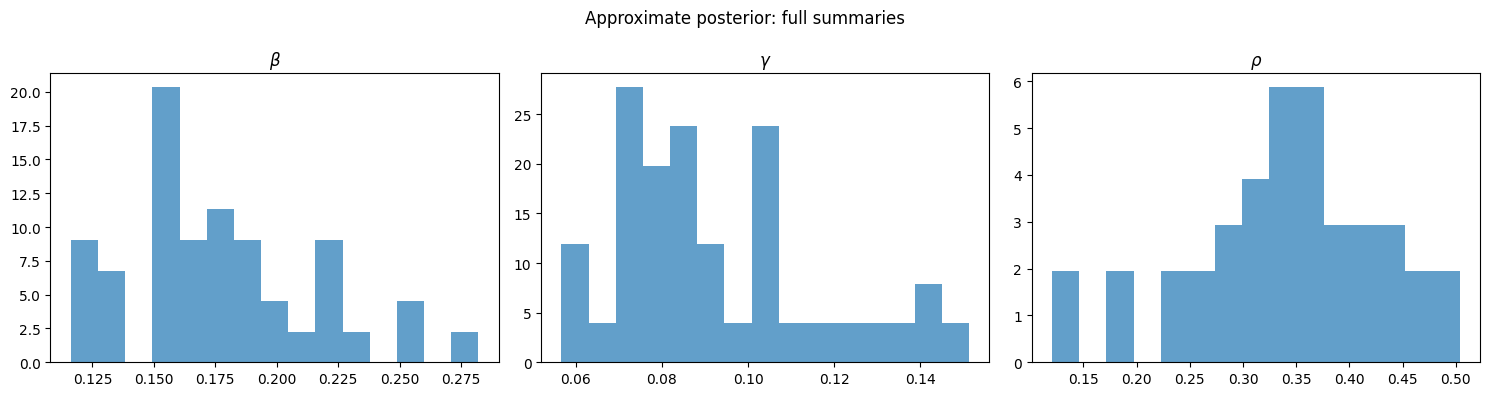

In [101]:
# Plot full-summary posterior
param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j in range(3):
    axes[j].hist(accepted_full_2pct[:, j], bins=15, density=True, alpha=0.7)
    axes[j].set_title(param_names[j])

plt.suptitle("Approximate posterior: full summaries")
plt.tight_layout()
plt.show()

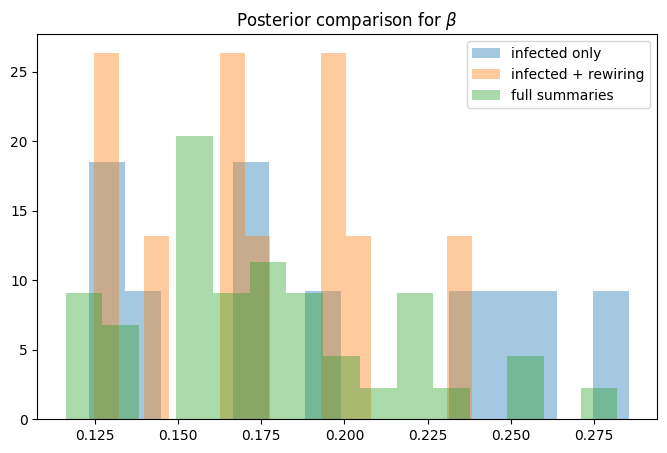

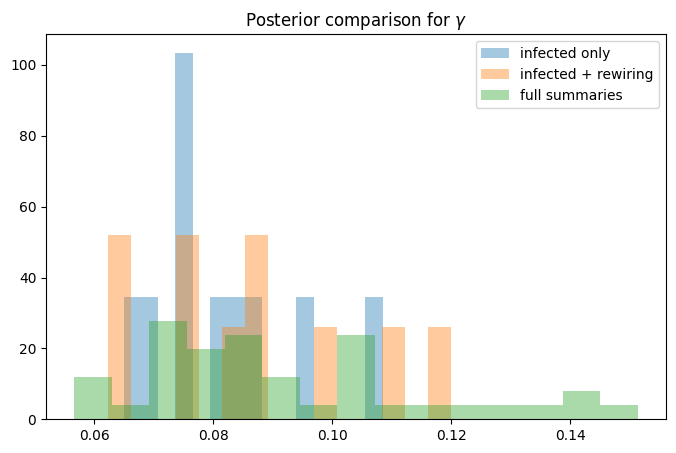

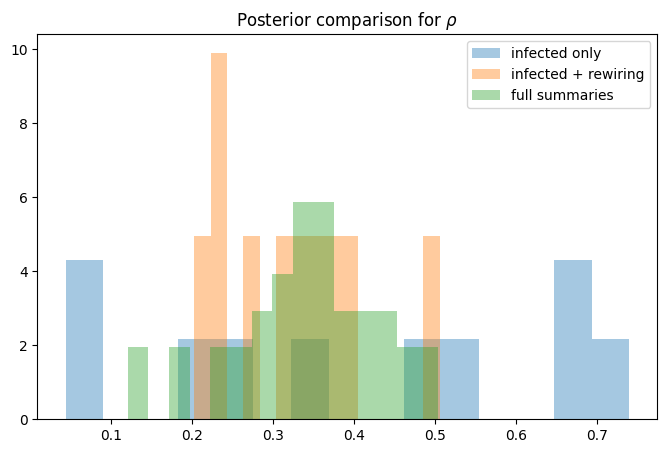

In [102]:
# Posterior comparison across summary sets
summary_sets = {
    "infected only": accepted_inf_only,
    "infected + rewiring": accepted_inf_rew,
    "full summaries": accepted_full_2pct,
}

param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]

for j in range(3):
    plt.figure(figsize=(8, 5))
    for label, samples in summary_sets.items():
        plt.hist(samples[:, j], bins=15, density=True, alpha=0.4, label=label)
    plt.title(f"Posterior comparison for {param_names[j]}")
    plt.legend()
    plt.show()

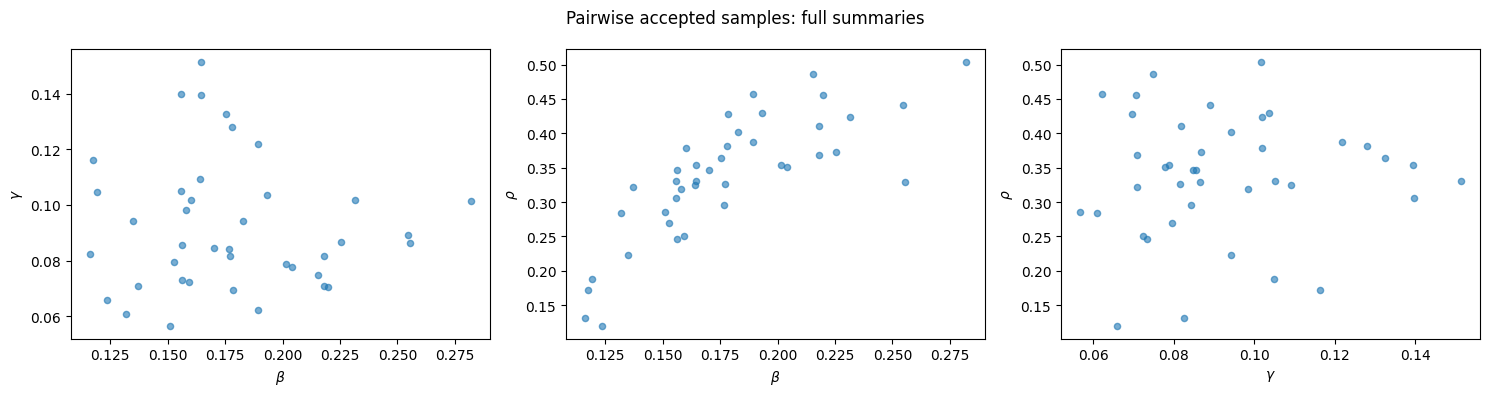

In [103]:
# Pairwise plots for full summaries
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(accepted_full_2pct[:, 0], accepted_full_2pct[:, 1], alpha=0.6, s=20)
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel(r"$\gamma$")

axes[1].scatter(accepted_full_2pct[:, 0], accepted_full_2pct[:, 2], alpha=0.6, s=20)
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"$\rho$")

axes[2].scatter(accepted_full_2pct[:, 1], accepted_full_2pct[:, 2], alpha=0.6, s=20)
axes[2].set_xlabel(r"$\gamma$")
axes[2].set_ylabel(r"$\rho$")

plt.suptitle("Pairwise accepted samples: full summaries")
plt.tight_layout()
plt.show()

# 6. Posterior predictive checks

In [104]:
# function to generate posterior predictive averages
def posterior_predictive_curves(accepted_samples, n_draws=30, n_reps=20, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    infected_curves = []
    rewiring_curves = []
    degree_hists = []

    idx = rng.choice(len(accepted_samples), size=n_draws, replace=True)

    for k in idx:
        beta, gamma, rho = accepted_samples[k]

        inf_reps = []
        rew_reps = []
        deg_reps = []

        for _ in range(n_reps):
            inf_curve, rew_curve, deg_hist = simulator.simulate(
                beta=beta, gamma=gamma, rho=rho, rng=rng
            )
            inf_reps.append(inf_curve)
            rew_reps.append(rew_curve)
            deg_reps.append(deg_hist)

        infected_curves.append(np.mean(np.vstack(inf_reps), axis=0))
        rewiring_curves.append(np.mean(np.vstack(rew_reps), axis=0))
        degree_hists.append(np.mean(np.vstack(deg_reps), axis=0))

    return np.vstack(infected_curves), np.vstack(rewiring_curves), np.vstack(degree_hists)

In [105]:
# generate posterior predictive draws from full summaries
rng = np.random.default_rng(123)

pp_inf, pp_rew, pp_deg = posterior_predictive_curves(
    accepted_full_2pct,
    n_draws=30,
    n_reps=20,
    rng=rng
)

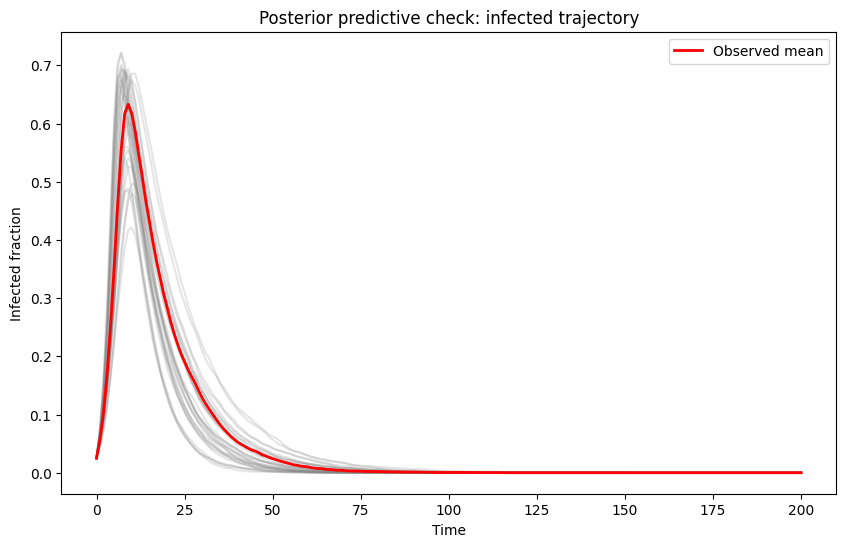

In [106]:
# compare infected trajectories
obs_inf_mean = infected_mean.values

plt.figure(figsize=(10, 6))
for row in pp_inf:
    plt.plot(row, color="gray", alpha=0.2)
plt.plot(obs_inf_mean, color="red", linewidth=2, label="Observed mean")

plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Posterior predictive check: infected trajectory")
plt.legend()
plt.show()

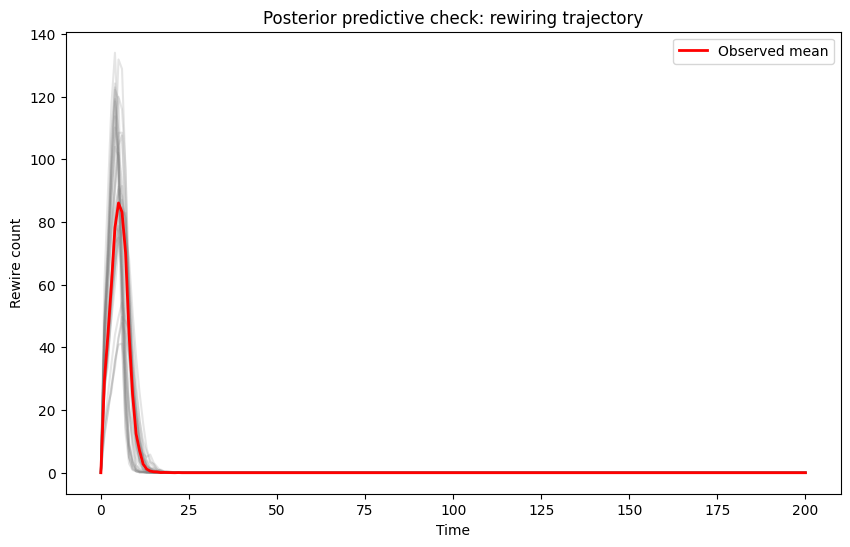

In [107]:
# compare rewiring trajectories
obs_rew_mean = rewiring_mean.values

plt.figure(figsize=(10, 6))
for row in pp_rew:
    plt.plot(row, color="gray", alpha=0.2)
plt.plot(obs_rew_mean, color="red", linewidth=2, label="Observed mean")

plt.xlabel("Time")
plt.ylabel("Rewire count")
plt.title("Posterior predictive check: rewiring trajectory")
plt.legend()
plt.show()

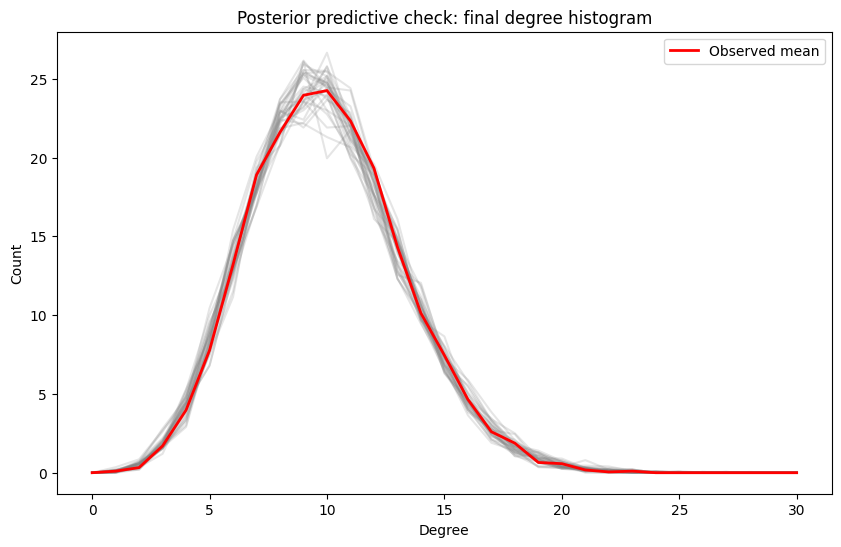

In [108]:
# compare final degree histograms
obs_deg_mean = degree_mean.values

plt.figure(figsize=(10, 6))
for row in pp_deg:
    plt.plot(np.arange(len(row)), row, color="gray", alpha=0.2)
plt.plot(np.arange(len(obs_deg_mean)), obs_deg_mean, color="red", linewidth=2, label="Observed mean")

plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Posterior predictive check: final degree histogram")
plt.legend()
plt.show()

# 7. Advanced method: regression adjustment

In [46]:
# ABC that stores summaries
def rejection_abc_store_summaries(n_samples, obs_summary, scale, n_reps_per_theta=10,
                                  use_infected=True, use_rewiring=True, use_degree=True,
                                  rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = sample_prior(n_samples, rng=rng)
    distances = np.zeros(n_samples)
    sim_summaries = []

    for i, (beta, gamma, rho) in enumerate(theta):
        sim_summary = simulate_average_summary(
            beta, gamma, rho,
            n_reps=n_reps_per_theta,
            use_infected=use_infected,
            use_rewiring=use_rewiring,
            use_degree=use_degree,
            rng=rng
        )

        sim_summaries.append(sim_summary)
        distances[i] = normalized_distance(sim_summary, obs_summary, scale)

        if (i + 1) % 100 == 0:
            print(f"Done {i+1}/{n_samples}")

    sim_summaries = np.vstack(sim_summaries)
    return theta, sim_summaries, distances

In [47]:
# Rerun full summaries with stored summaries at 2000 sampl full-summary ABC with stored summaries
rng = np.random.default_rng(123)

theta_full_store, simsum_full_store, dist_full_store = rejection_abc_store_summaries(
    n_samples=2000,
    obs_summary=obs_sum_full,
    scale=scale_full,
    n_reps_per_theta=5,
    use_infected=True,
    use_rewiring=True,
    use_degree=True,
    rng=rng
)

Done 100/2000
Done 200/2000
Done 300/2000
Done 400/2000
Done 500/2000
Done 600/2000
Done 700/2000
Done 800/2000
Done 900/2000
Done 1000/2000
Done 1100/2000
Done 1200/2000
Done 1300/2000
Done 1400/2000
Done 1500/2000
Done 1600/2000
Done 1700/2000
Done 1800/2000
Done 1900/2000
Done 2000/2000


In [48]:
# Extract accepted 2% and 5% sets
eps_store_2pct = np.quantile(dist_full_store, 0.02)
mask_store_2pct = dist_full_store <= eps_store_2pct

accepted_theta_2pct = theta_full_store[mask_store_2pct]
accepted_simsum_2pct = simsum_full_store[mask_store_2pct]

eps_store_5pct = np.quantile(dist_full_store, 0.05)
mask_store_5pct = dist_full_store <= eps_store_5pct

accepted_theta_5pct = theta_full_store[mask_store_5pct]
accepted_simsum_5pct = simsum_full_store[mask_store_5pct]

print("Stored version accepted counts:")
print("2%:", len(accepted_theta_2pct))
print("5%:", len(accepted_theta_5pct))

Stored version accepted counts:
2%: 40
5%: 100


In [49]:
# regression-adjustment function
def regression_adjustment(theta_acc, simsum_acc, obs_summary, n_components=10):
    """
    Regression adjustment with PCA dimensionality reduction using NumPy only.
    """
    import numpy as np

    X0 = simsum_acc - obs_summary

    # center predictors
    X_centered = X0 - X0.mean(axis=0)

    # choose safe number of components
    n_components = min(n_components, X_centered.shape[0] - 1, X_centered.shape[1])

    # SVD-based PCA
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # principal component scores
    X_pca = U[:, :n_components] * S[:n_components]

    # regression design matrix
    X = np.column_stack([np.ones(len(X_pca)), X_pca])

    theta_adj = np.zeros_like(theta_acc)

    for j in range(theta_acc.shape[1]):
        y = theta_acc[:, j]
        coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        fitted_offset = X[:, 1:] @ coef[1:]   # exclude intercept
        theta_adj[:, j] = y - fitted_offset

    return theta_adj

#### trying with 5%

In [50]:
# apply regression adjustment to the 5% set
theta_full_adj_5pct = regression_adjustment(
    accepted_theta_5pct,
    accepted_simsum_5pct,
    obs_sum_full,
    n_components=10
)

print("Original 5% posterior mean:", accepted_theta_5pct.mean(axis=0))
print("Original 5% posterior std :", accepted_theta_5pct.std(axis=0))
print("Adjusted posterior mean:", theta_full_adj_5pct.mean(axis=0))
print("Adjusted posterior std :", theta_full_adj_5pct.std(axis=0))

print("Any NaN?", np.isnan(theta_full_adj_5pct).any())
print("Any inf?", np.isinf(theta_full_adj_5pct).any())
print("Adjusted mins:", theta_full_adj_5pct.min(axis=0))
print("Adjusted maxs:", theta_full_adj_5pct.max(axis=0))

Original 5% posterior mean: [0.19831974 0.10065087 0.35032134]
Original 5% posterior std : [0.04952995 0.03021903 0.11227986]
Adjusted posterior mean: [0.19831974 0.10065087 0.35032134]
Adjusted posterior std : [0.0145623  0.00945947 0.0179352 ]
Any NaN? False
Any inf? False
Adjusted mins: [0.16830162 0.07969817 0.31605853]
Adjusted maxs: [0.23860514 0.12873026 0.41182452]


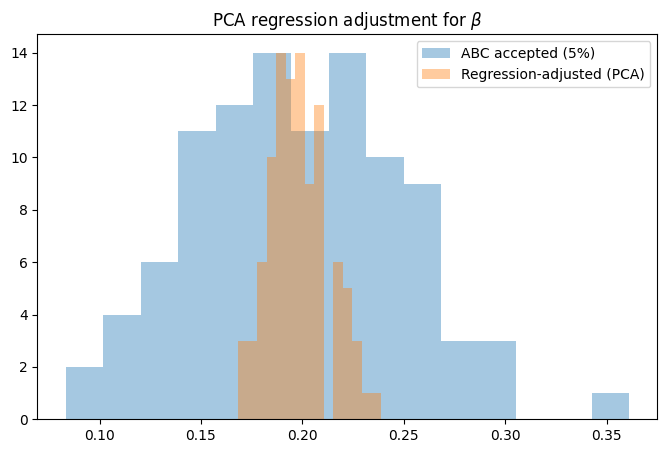

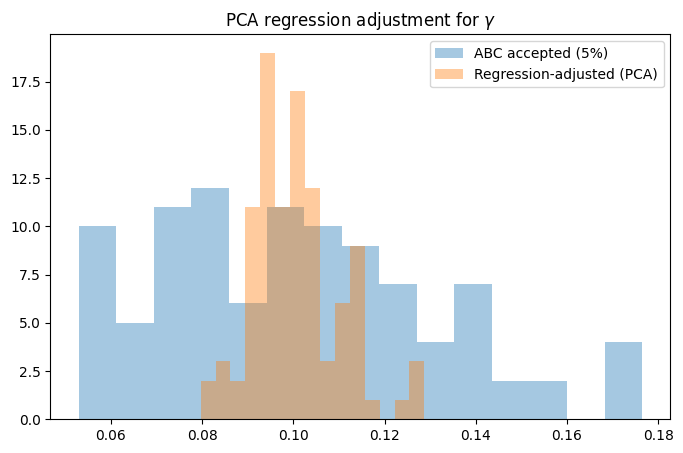

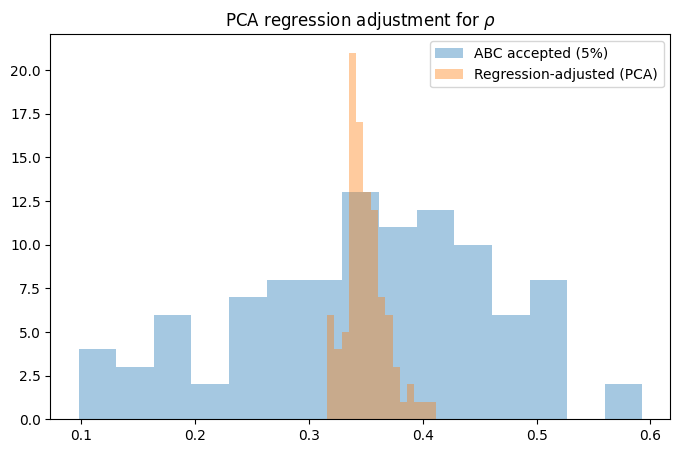

In [134]:
# Plot before vs after regression adjustment
param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]

for j in range(3):
    plt.figure(figsize=(8, 5))
    plt.hist(accepted_theta_5pct[:, j], bins=15, alpha=0.4, label="ABC accepted (5%)")
    plt.hist(theta_full_adj_5pct[:, j], bins=15, alpha=0.4, label="Regression-adjusted (PCA)")
    plt.title(f"PCA regression adjustment for {param_names[j]}")
    plt.legend()
    plt.show()

### Regression-Adjusted ABC: Interpretation

- A PCA-based regression-adjustment post-processing step was applied to the accepted 5% ABC sample.
- Dimensionality reduction was used to stabilize the adjustment because the original summary vector was high-dimensional and strongly correlated.
- The adjusted posterior mean remained essentially unchanged, indicating that the correction did not materially shift the posterior center.
- The main effect of regression adjustment was to reduce posterior spread, producing a more concentrated posterior for all three parameters.
- regression adjustment is best interpreted as a variance-reduction or sharpening step rather than a major change in point estimates.

# 8. Advanced Method: SMC-ABC Implementation

Rejection ABC samples blindly from the prior, most proposals are immediately rejected. 
SMC-ABC instead runs a sequence of decreasing tolerance thresholds, focusing particles 
progressively closer to the observed data. At each stage, surviving particles are 
resampled and perturbed with a Gaussian kernel, making each stage more efficient than 
the last.

In [119]:
#prior bounds helper
def in_prior_bounds(theta):
    beta, gamma, rho = theta
    return (0.05 <= beta <= 0.50) and (0.02 <= gamma <= 0.20) and (0.00 <= rho <= 0.80)

In [120]:
#Perturbation helper
def perturb_theta(theta, scales, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return theta + rng.normal(0, scales, size=3)

In [121]:
# simple SMC-ABC
def smc_abc(obs_summary, scale, eps_schedule, n_particles=100, n_reps_per_theta=5,
            use_infected=True, use_rewiring=True, use_degree=True,
            rng=None):
    if rng is None:
        rng = np.random.default_rng()

    populations = []
    population_distances = []

    for t, eps in enumerate(eps_schedule):
        accepted_particles = []
        accepted_distances = []

        print(f"\nSMC round {t+1}/{len(eps_schedule)} with epsilon = {eps}")

        if t == 0:
            while len(accepted_particles) < n_particles:
                theta = sample_prior(1, rng=rng)[0]

                sim_summary = simulate_average_summary(
                    theta[0], theta[1], theta[2],
                    n_reps=n_reps_per_theta,
                    use_infected=use_infected,
                    use_rewiring=use_rewiring,
                    use_degree=use_degree,
                    rng=rng
                )

                d = normalized_distance(sim_summary, obs_summary, scale)

                if d <= eps:
                    accepted_particles.append(theta)
                    accepted_distances.append(d)

                if len(accepted_particles) > 0 and len(accepted_particles) % 20 == 0:
                    print(f"  accepted {len(accepted_particles)}/{n_particles}")

        else:
            prev_particles = populations[-1]

            kernel_scales = np.std(prev_particles, axis=0)
            kernel_scales[kernel_scales == 0] = 1e-3

            while len(accepted_particles) < n_particles:
                parent_idx = rng.integers(len(prev_particles))
                parent = prev_particles[parent_idx]

                theta = perturb_theta(parent, kernel_scales, rng=rng)

                if not in_prior_bounds(theta):
                    continue

                sim_summary = simulate_average_summary(
                    theta[0], theta[1], theta[2],
                    n_reps=n_reps_per_theta,
                    use_infected=use_infected,
                    use_rewiring=use_rewiring,
                    use_degree=use_degree,
                    rng=rng
                )

                d = normalized_distance(sim_summary, obs_summary, scale)

                if d <= eps:
                    accepted_particles.append(theta)
                    accepted_distances.append(d)

                if len(accepted_particles) > 0 and len(accepted_particles) % 20 == 0:
                    print(f"  accepted {len(accepted_particles)}/{n_particles}")

        accepted_particles = np.vstack(accepted_particles)
        accepted_distances = np.array(accepted_distances)

        populations.append(accepted_particles)
        population_distances.append(accepted_distances)

        print("  posterior mean:", accepted_particles.mean(axis=0))
        print("  posterior std :", accepted_particles.std(axis=0))

    return populations, population_distances

In [122]:
# epsilon schedule
eps_schedule = [4.0, 3.4, 2.8, 2.5]

In [123]:
# run SMC-ABC on full summaries
rng = np.random.default_rng(123)

smc_pops, smc_dists = smc_abc(
    obs_summary=obs_sum_full,
    scale=scale_full,
    eps_schedule=eps_schedule,
    n_particles=100,
    n_reps_per_theta=5,
    use_infected=True,
    use_rewiring=True,
    use_degree=True,
    rng=rng
)


SMC round 1/4 with epsilon = 4.0
  accepted 20/100
  accepted 20/100
  accepted 40/100
  accepted 40/100
  accepted 40/100
  accepted 40/100
  accepted 40/100
  accepted 60/100
  accepted 80/100
  accepted 80/100
  accepted 80/100
  accepted 80/100
  accepted 100/100
  posterior mean: [0.30433346 0.11650716 0.34813527]
  posterior std : [0.09992503 0.0389274  0.20225105]

SMC round 2/4 with epsilon = 3.4
  accepted 20/100
  accepted 40/100
  accepted 60/100
  accepted 60/100
  accepted 80/100
  accepted 80/100
  accepted 80/100
  accepted 80/100
  accepted 80/100
  accepted 100/100
  posterior mean: [0.26969873 0.11284455 0.38308184]
  posterior std : [0.08639437 0.03369584 0.1710116 ]

SMC round 3/4 with epsilon = 2.8
  accepted 20/100
  accepted 20/100
  accepted 40/100
  accepted 40/100
  accepted 40/100
  accepted 40/100
  accepted 40/100
  accepted 60/100
  accepted 60/100
  accepted 80/100
  accepted 100/100
  posterior mean: [0.2294508  0.10992319 0.37151654]
  posterior std : 

In [124]:
# Extract the final SMC population
smc_final = smc_pops[-1]

print("Final SMC population shape:", smc_final.shape)
print("Final SMC posterior mean:", smc_final.mean(axis=0))
print("Final SMC posterior std :", smc_final.std(axis=0))

Final SMC population shape: (100, 3)
Final SMC posterior mean: [0.22179003 0.10781328 0.37903273]
Final SMC posterior std : [0.04640062 0.02623926 0.10042464]


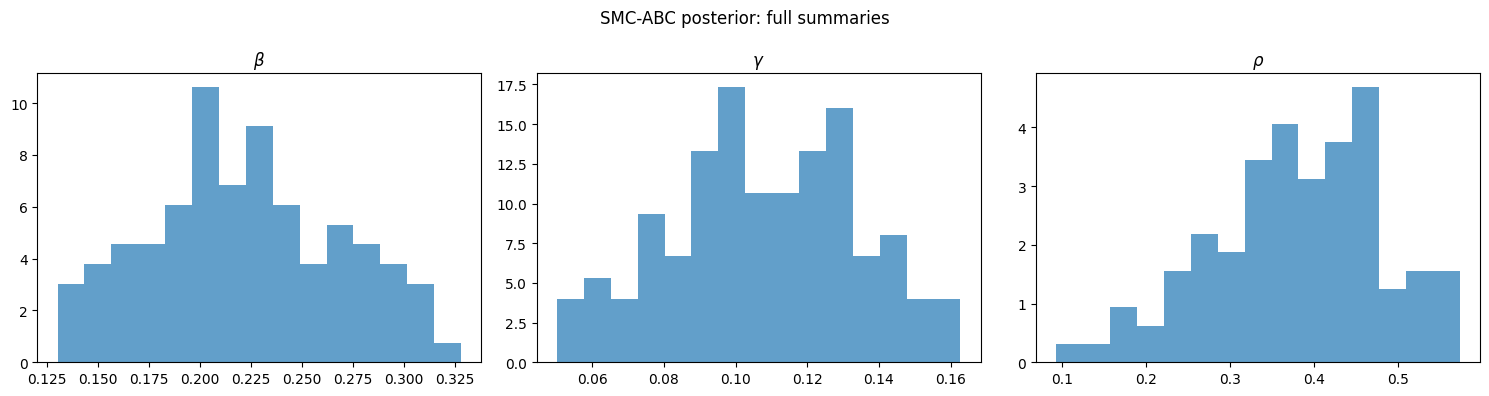

In [125]:
# Plot the final SMC posterior histograms
param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j in range(3):
    axes[j].hist(smc_final[:, j], bins=15, density=True, alpha=0.7)
    axes[j].set_title(param_names[j])

plt.suptitle("SMC-ABC posterior: full summaries")
plt.tight_layout()
plt.show()

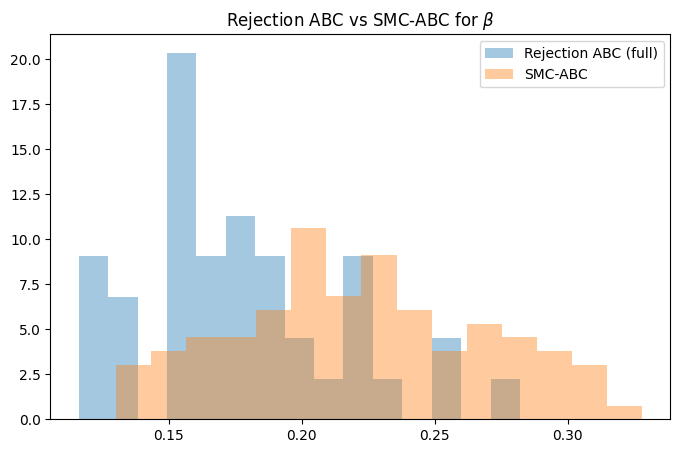

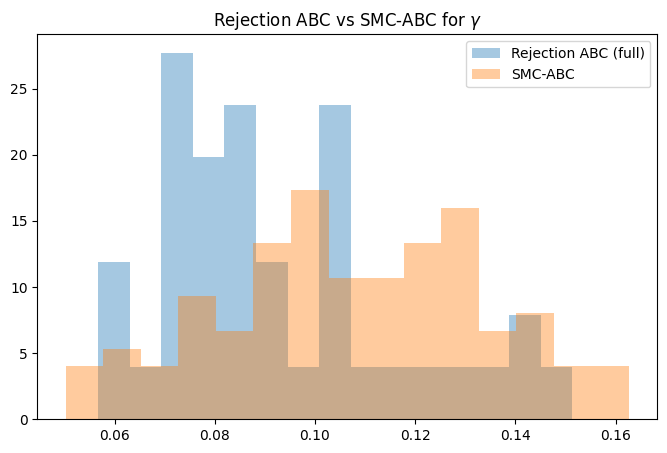

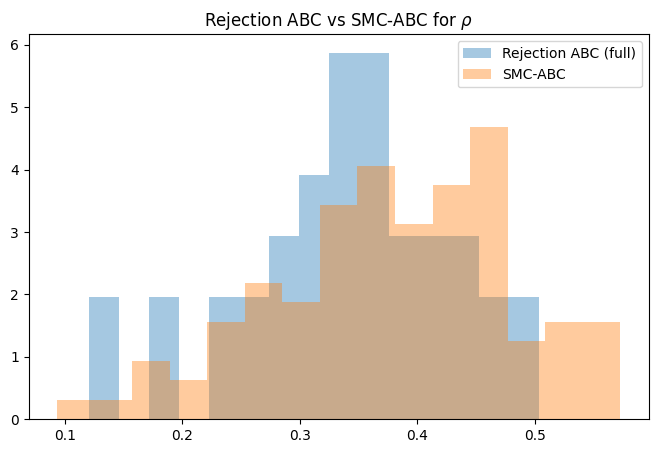

In [126]:
# Compare rejection ABC vs SMC-ABC
comparison_sets = {
    "Rejection ABC (full)": accepted_full_2pct,
    "SMC-ABC": smc_final
}

param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]

for j in range(3):
    plt.figure(figsize=(8, 5))
    for label, samples in comparison_sets.items():
        plt.hist(samples[:, j], bins=15, density=True, alpha=0.4, label=label)
    plt.title(f"Rejection ABC vs SMC-ABC for {param_names[j]}")
    plt.legend()
    plt.show()

In [137]:
# final comparison table
results_table = pd.DataFrame({
    "method": [
        "infected only (500, 2%)",
        "infected + rewiring (500, 2%)",
        "full summaries (2000, 2%)",
        "full summaries (2000, 5%)",
        "full + reg adj PCA (2000, 5%)",
        "SMC-ABC"
    ],
    
    "beta_mean": [
        accepted_inf_only.mean(axis=0)[0],
        accepted_inf_rew.mean(axis=0)[0],
        accepted_full_2pct.mean(axis=0)[0],
        accepted_full_5pct.mean(axis=0)[0],
        theta_full_adj_5pct.mean(axis=0)[0],
        smc_final.mean(axis=0)[0],
    ],
    "beta_std": [
        accepted_inf_only.std(axis=0)[0],
        accepted_inf_rew.std(axis=0)[0],
        accepted_full_2pct.std(axis=0)[0],
        accepted_full_5pct.std(axis=0)[0],
        theta_full_adj_5pct.std(axis=0)[0],
        smc_final.std(axis=0)[0],
    ],
    
    "gamma_mean": [
        accepted_inf_only.mean(axis=0)[1],
        accepted_inf_rew.mean(axis=0)[1],
        accepted_full_2pct.mean(axis=0)[1],
        accepted_full_5pct.mean(axis=0)[1],
        theta_full_adj_5pct.mean(axis=0)[1],
        smc_final.mean(axis=0)[1],
    ],
    "gamma_std": [
        accepted_inf_only.std(axis=0)[1],
        accepted_inf_rew.std(axis=0)[1],
        accepted_full_2pct.std(axis=0)[1],
        accepted_full_5pct.std(axis=0)[1],
        theta_full_adj_5pct.std(axis=0)[1],
        smc_final.std(axis=0)[1],
    ],
    
    "rho_mean": [
        accepted_inf_only.mean(axis=0)[2],
        accepted_inf_rew.mean(axis=0)[2],
        accepted_full_2pct.mean(axis=0)[2],
        accepted_full_5pct.mean(axis=0)[2],
        theta_full_adj_5pct.mean(axis=0)[2],
        smc_final.mean(axis=0)[2],
    ],
    "rho_std": [
        accepted_inf_only.std(axis=0)[2],
        accepted_inf_rew.std(axis=0)[2],
        accepted_full_2pct.std(axis=0)[2],
        accepted_full_5pct.std(axis=0)[2],
        theta_full_adj_5pct.std(axis=0)[2],
        smc_final.std(axis=0)[2],
    ],
})

results_table

,method,beta_mean,beta_std,gamma_mean,gamma_std,rho_mean,rho_std
0,"infected only (500, 2%)",0.194894,0.056478,0.082173,0.012132,0.401020,0.249882
1,"infected + rewiring (500, 2%)",0.175123,0.034206,0.086529,0.017621,0.322363,0.087612
2,"full summaries (2000, 2%)",0.177909,0.038875,0.092257,0.023083,0.337498,0.088612
3,"full summaries (2000, 5%)",0.198320,0.049530,0.100651,0.030219,0.350321,0.112280
4,"full + reg adj PCA (2000, 5%)",0.198320,0.014562,0.100651,0.009459,0.350321,0.017935
5,SMC-ABC,0.221790,0.046401,0.107813,0.026239,0.379033,0.100425


## Appendix: Parameter Sensitivity Exploration

### Effect of β (vary this and keep other params fixed)

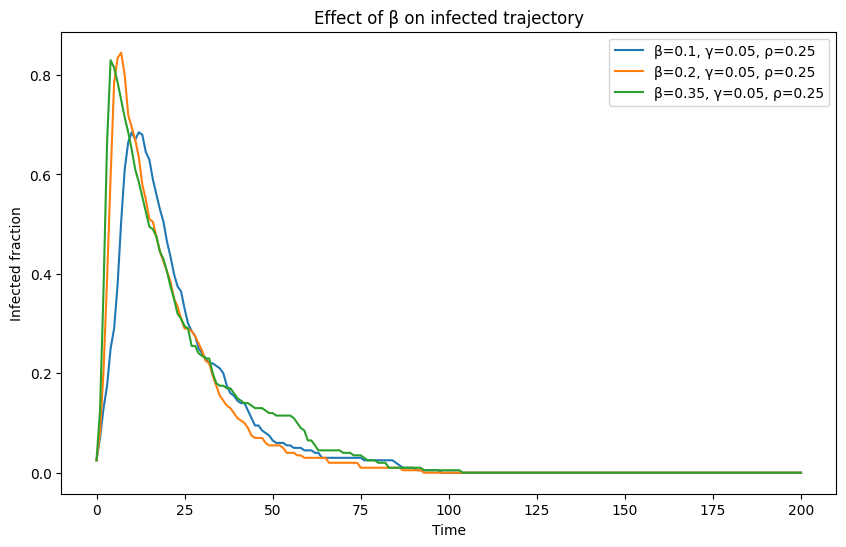

In [33]:
plt.figure(figsize=(10, 6))

param_list = [
    (0.10, 0.05, 0.25),
    (0.20, 0.05, 0.25),
    (0.35, 0.05, 0.25),
]

for beta, gamma, rho in param_list:
    inf_curve, rew_curve, deg_hist = simulator.simulate(beta=beta, gamma=gamma, rho=rho)
    plt.plot(inf_curve, label=f"β={beta}, γ={gamma}, ρ={rho}")

plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Effect of β on infected trajectory")
plt.legend()
plt.show()

 β plots suggest:
 
- Changing β clearly affects the early growth and peak behavior
- Higher β tends to produce a faster and more explosive outbreak
 
This is normal. For example, the β=0.2 curve peaking above β=0.35 in that one run does not mean β=0.2 is truly "more infectious." It just means that one random realization happened to produce a bigger outbreak.
 
Main Takeaway
 
β is strongly reflected in:
 
- Peak infected fraction
- Time to peak
- Overall epidemic burden

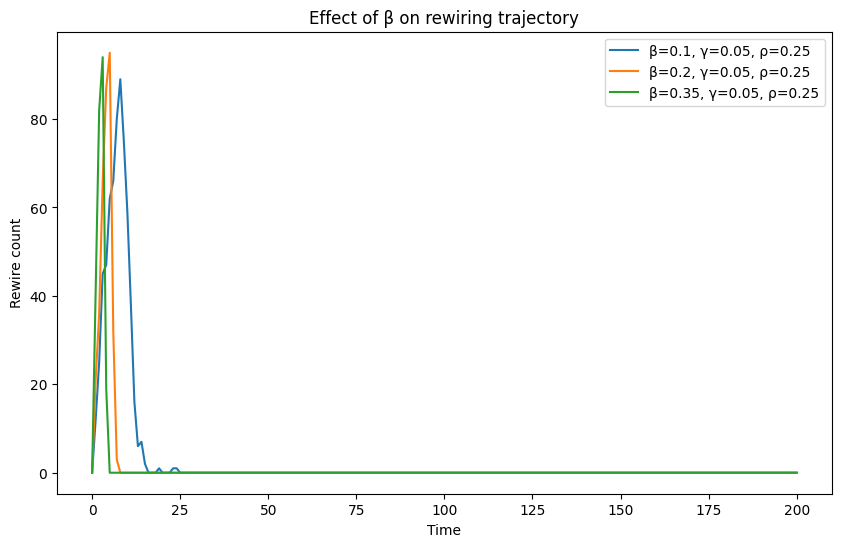

In [34]:
plt.figure(figsize=(10, 6))

for beta, gamma, rho in param_list:
    inf_curve, rew_curve, deg_hist = simulator.simulate(beta=beta, gamma=gamma, rho=rho)
    plt.plot(rew_curve, label=f"β={beta}, γ={gamma}, ρ={rho}")

plt.xlabel("Time")
plt.ylabel("Rewire count")
plt.title("Effect of β on rewiring trajectory")
plt.legend()
plt.show()

The rewiring curves show:
 
- Rewiring happens in a narrow early window
- When infection spreads differently, rewiring activity also changes indirectly
- So rewiring is not only about ρ, it also depends on how many S–I edges exist, which is influenced by β
 
Main Takeaway
 
Rewiring counts are influenced by β, but not as directly as by ρ.
 

### Effect of γ

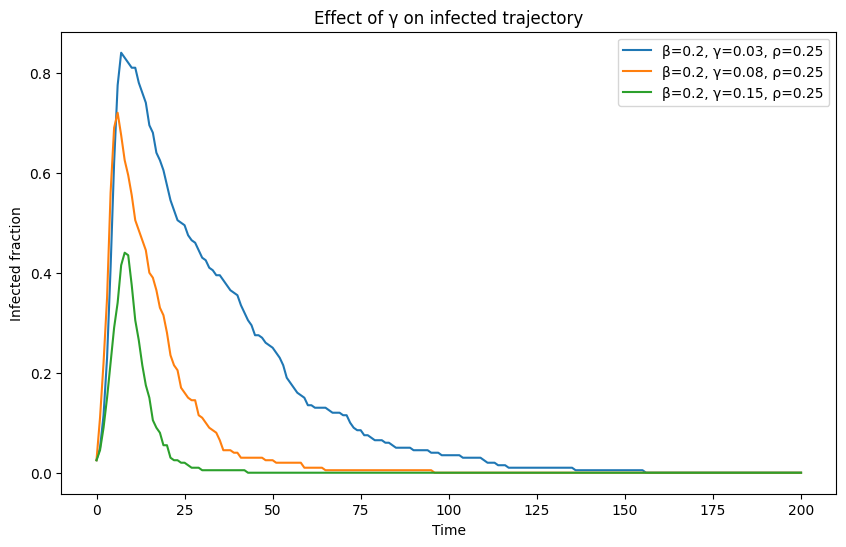

In [35]:
plt.figure(figsize=(10, 6))

param_list = [
    (0.20, 0.03, 0.25),
    (0.20, 0.08, 0.25),
    (0.20, 0.15, 0.25),
]

for beta, gamma, rho in param_list:
    inf_curve, rew_curve, deg_hist = simulator.simulate(beta=beta, gamma=gamma, rho=rho)
    plt.plot(inf_curve, label=f"β={beta}, γ={gamma}, ρ={rho}")

plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Effect of γ on infected trajectory")
plt.legend()
plt.show()

The γ plot clearly shows:
 
- Higher γ gives a shorter outbreak
- Higher γ lowers the peak and makes the curve fall much faster
- Lower γ gives a long heavy tail
 
Main Takeaway
 
γ strongly affects:
 
- Outbreak duration
- Tail decay
- Final return to zero

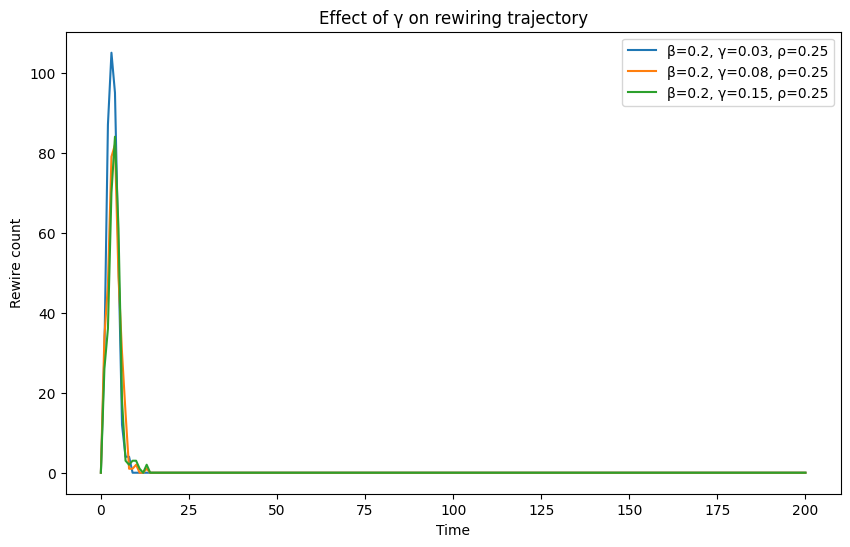

In [36]:
plt.figure(figsize=(10, 6))

for beta, gamma, rho in param_list:
    inf_curve, rew_curve, deg_hist = simulator.simulate(beta=beta, gamma=gamma, rho=rho)
    plt.plot(rew_curve, label=f"β={beta}, γ={gamma}, ρ={rho}")

plt.xlabel("Time")
plt.ylabel("Rewire count")
plt.title("Effect of γ on rewiring trajectory")
plt.legend()
plt.show()

The rewiring plot suggests:
 
- When recovery is faster, rewiring dies out earlier
- Rewiring duration seems shorter for higher γ
- But the effect is weaker than what you saw on infected fraction
 
Main Takeaway
 
γ affects rewiring indirectly through epidemic duration.

### Effect of ρ

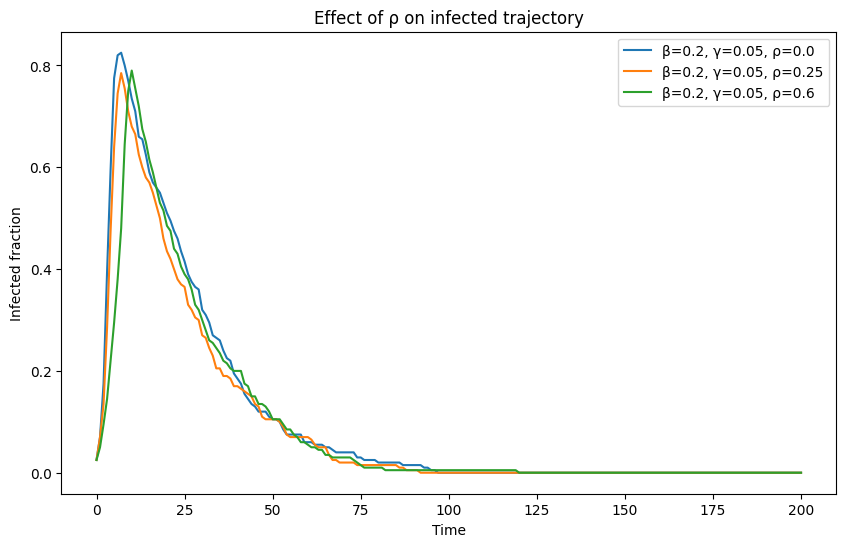

In [37]:
plt.figure(figsize=(10, 6))

param_list = [
    (0.20, 0.05, 0.00),
    (0.20, 0.05, 0.25),
    (0.20, 0.05, 0.60),
]

for beta, gamma, rho in param_list:
    inf_curve, rew_curve, deg_hist = simulator.simulate(beta=beta, gamma=gamma, rho=rho)
    plt.plot(inf_curve, label=f"β={beta}, γ={gamma}, ρ={rho}")

plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.title("Effect of ρ on infected trajectory")
plt.legend()
plt.show()

The plot shows:
 
- Higher ρ tends to suppress the epidemic somewhat
- The differences are there, but they are not huge in this one-run example
 
Main Takeaway
 
If only look at infected curves, it may be hard to cleanly separate:
 
- Lower β from
- Higher ρ
 
That is why use rewiring counts and degree histograms too.

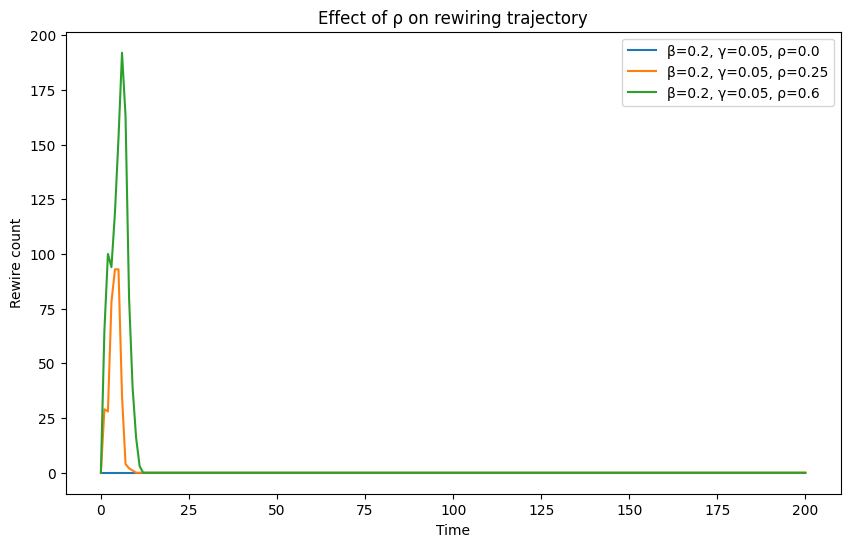

In [38]:
plt.figure(figsize=(10, 6))

for beta, gamma, rho in param_list:
    inf_curve, rew_curve, deg_hist = simulator.simulate(beta=beta, gamma=gamma, rho=rho)
    plt.plot(rew_curve, label=f"β={beta}, γ={gamma}, ρ={rho}")

plt.xlabel("Time")
plt.ylabel("Rewire count")
plt.title("Effect of ρ on rewiring trajectory")
plt.legend()
plt.show()

The plot shows:
 
- ρ=0 gives essentially no rewiring
- Larger ρ sharply increases rewiring counts
- So rewiring counts respond very directly to ρ
 
Main Takeaway
 
Rewiring summaries should be highly informative for ρ.

#### notes:
- **Increasing β** changes the epidemic peak and early growth, although single-run comparisons are noisy because of stochastic variability.
- **Increasing γ** clearly shortens the outbreak and leads to a faster decline in infected fraction.
- **Increasing ρ** raises rewiring counts substantially and tends to suppress infection through adaptive rewiring.
- Rewiring counts appear especially informative for **ρ**, whereas infected trajectories reflect all three parameters.
- Since both **β** and **ρ** influence epidemic suppression, infected trajectories alone may not fully separate them.